In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [2]:
# load the train and test data
X_train, y_train = joblib.load('../models/train_data.pkl')
X_test, y_test = joblib.load('../models/test_data.pkl')

# verify the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (454902, 30)
X_test shape: (56962, 30)
y_train shape: (454902,)
y_test shape: (56962,)


In [3]:
# model training

model = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', 
                             random_state=42, n_estimators=100)
}

#fit the models
trained_model = {}
predictions = {}

for name, model in model.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_model[name] = model
    predictions[name] = model.predict(X_test)
    print(f"{name} training completed.\n")

Training Logistic Regression...
Logistic Regression training completed.

Training Random Forest...
Random Forest training completed.

Training XGBoost...


c:\Users\Segun\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [07:34:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost training completed.



In [4]:
# Evaluate the models
for name, preds in predictions.items():
    proba = trained_model[name].predict_proba(X_test)[:, 1]
    class_report = classification_report(y_test, preds)
    conf_matrix = confusion_matrix(y_test, preds)
    print(f"Evaluating {name}...\n")
    print(f"classification report\n {class_report}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")
    roc_auc = roc_auc_score(y_test, proba)
    print(f"ROC AUC Score: {roc_auc:.4f}\n")
    
    # double line separator
    print("=" * 60 + "\n")

Evaluating Logistic Regression...

classification report
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Confusion Matrix:
[[55397  1467]
 [    8    90]]

ROC AUC Score: 0.9708


Evaluating Random Forest...

classification report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56852    12]
 [   17    81]]

ROC AUC Score: 0.9685


Evaluating XGBoost...

classification report
               precision    recall  f1-scor

In [5]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Precision (Fraud)': [0.06, 0.87, 0.73],
    'Recall (Fraud)':    [0.92, 0.83, 0.85],
    'F1 (Fraud)':        [0.11, 0.85, 0.78],
    'ROC-AUC':           [0.9708, 0.9685, 0.9800],
    'False Positives':   [1467, 12, 31],
    'False Negatives':   [8, 17, 15]
})

summary.set_index('Model', inplace=True)
print(summary)

                     Precision (Fraud)  Recall (Fraud)  F1 (Fraud)  ROC-AUC  \
Model                                                                         
Logistic Regression               0.06            0.92        0.11   0.9708   
Random Forest                     0.87            0.83        0.85   0.9685   
XGBoost                           0.73            0.85        0.78   0.9800   

                     False Positives  False Negatives  
Model                                                  
Logistic Regression             1467                8  
Random Forest                     12               17  
XGBoost                           31               15  


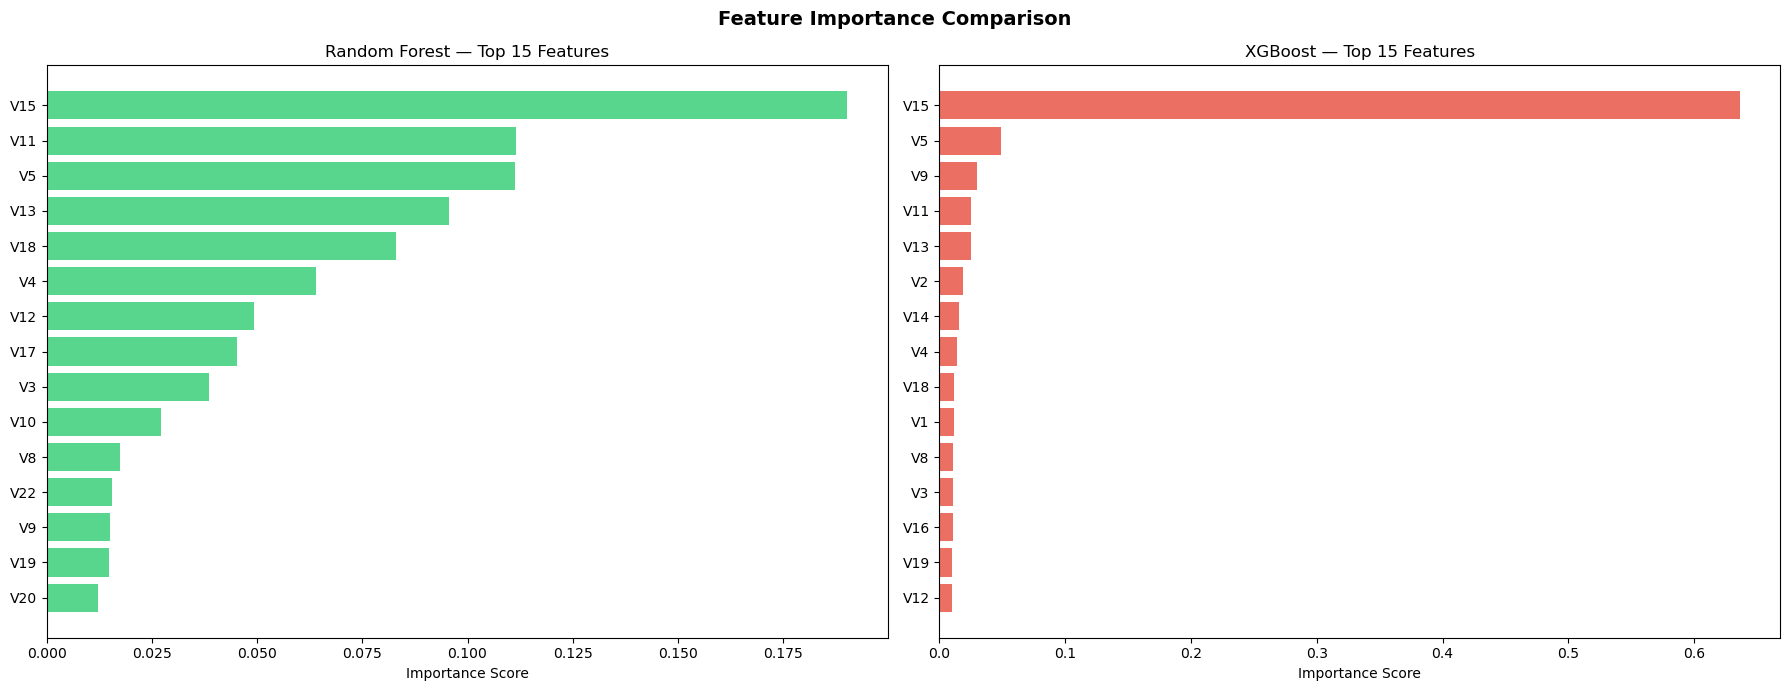

Random Forest — Top 10 Features:
V15    0.190334
V11    0.111533
V5     0.111358
V13    0.095698
V18    0.082916
V4     0.063938
V12    0.049284
V17    0.045134
V3     0.038536
V10    0.027124

XGBoost — Top 10 Features:
V15    0.636343
V5     0.048840
V9     0.029928
V11    0.025242
V13    0.024856
V2     0.018871
V14    0.015192
V4     0.013653
V18    0.011744
V1     0.011511


In [6]:
feature_names = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Random Forest importance
rf_importance = pd.Series(
    trained_model['Random Forest'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

axes[0].barh(rf_importance.index[::-1], 
             rf_importance.values[::-1], 
             color='#2ecc71', alpha=0.8)
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance Score')

# XGBoost importance
xgb_importance = pd.Series(
    trained_model['XGBoost'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

axes[1].barh(xgb_importance.index[::-1], 
             xgb_importance.values[::-1], 
             color='#e74c3c', alpha=0.8)
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 10 for each
print("Random Forest — Top 10 Features:")
print(rf_importance.head(10).to_string())
print("\nXGBoost — Top 10 Features:")
print(xgb_importance.head(10).to_string())

## Feature Importance Findings

- V15 is the single most important feature for both models
- XGBoost concentrates 63.6% of its importance on V15 alone
- Random Forest distributes importance more evenly across features
- EDA correlation identified V17/V14 as top features but models 
  prefer V15 — suggesting V15 has strong non-linear fraud signal
- Both models agree on V15, V11, V5, V13, V18, V4 as key features

Calculating permutation importance for Random Forest...
Calculating permutation importance for XGBoost...


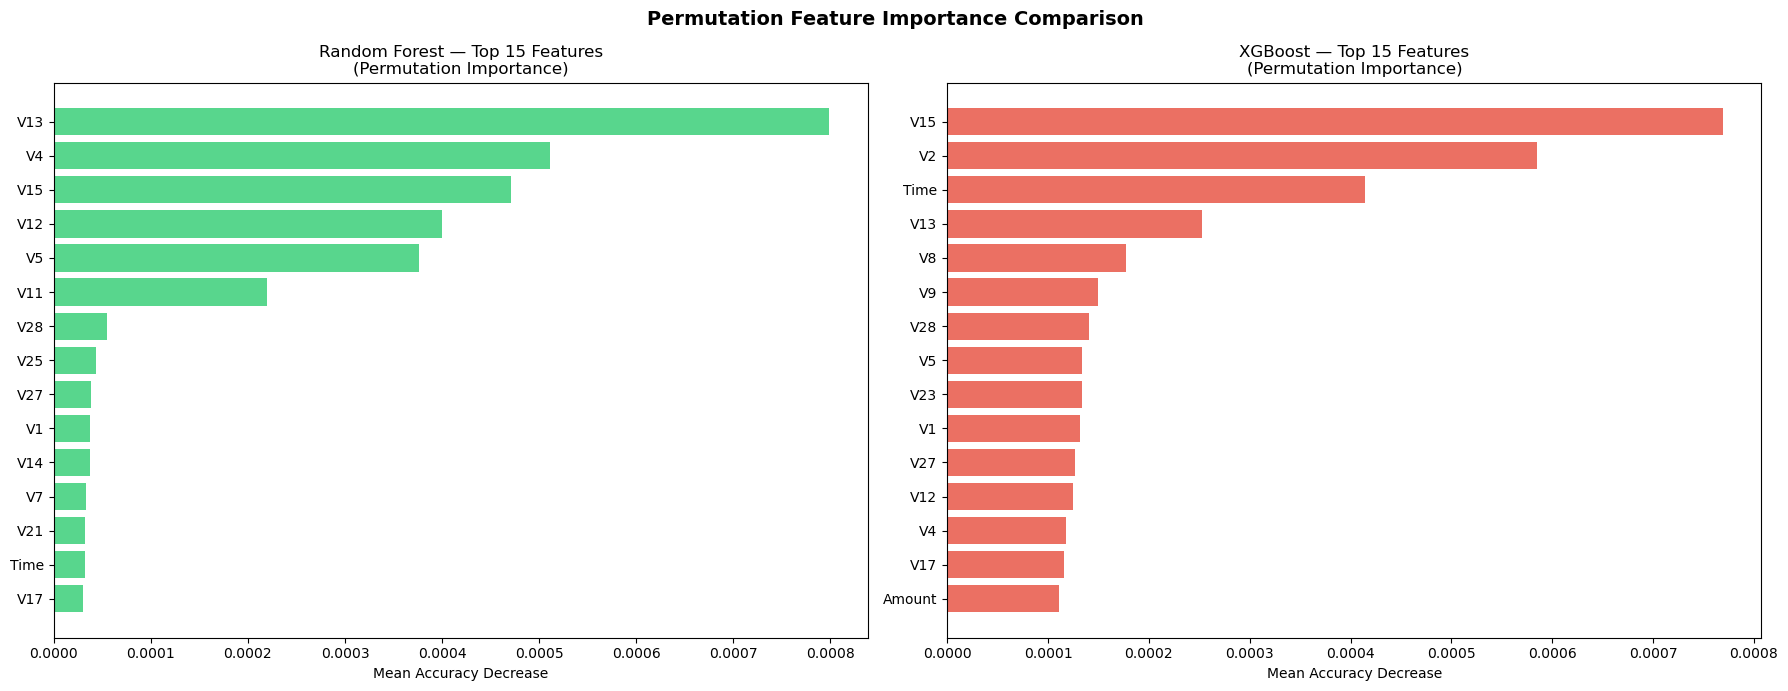

In [7]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (name, color) in enumerate([
    ('Random Forest', '#2ecc71'),
    ('XGBoost',       '#e74c3c')
]):
    model = trained_model[name]

    # Calculate permutation importance on test data
    print(f"Calculating permutation importance for {name}...")
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Build importance series
    perm_importance = pd.Series(
        result.importances_mean,
        index=feature_names
    ).sort_values(ascending=False).head(15)

    # Plot
    axes[idx].barh(perm_importance.index[::-1],
                   perm_importance.values[::-1],
                   color=color, alpha=0.8)
    axes[idx].set_title(f'{name} — Top 15 Features\n(Permutation Importance)')
    axes[idx].set_xlabel('Mean Accuracy Decrease')

plt.suptitle('Permutation Feature Importance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
for name in ['Random Forest', 'XGBoost']:
    model = trained_model[name]
    
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )
    
    perm_importance = pd.Series(
        result.importances_mean,
        index=feature_names
    ).sort_values(ascending=False).head(10)
    
    print(f"\n{name} — Top 10 Features (Permutation Importance):")
    print(perm_importance.to_string())


Random Forest — Top 10 Features (Permutation Importance):
V13    0.000799
V4     0.000511
V15    0.000470
V12    0.000400
V5     0.000376
V11    0.000219
V28    0.000054
V25    0.000044
V27    0.000039
V1     0.000037

XGBoost — Top 10 Features (Permutation Importance):
V15     0.000769
V2      0.000585
Time    0.000414
V13     0.000253
V8      0.000177
V9      0.000149
V28     0.000140
V5      0.000133
V23     0.000133
V1      0.000132


## Permutation Importance Findings

- V13 is Random Forest's true most important feature — not V15
- V15 was overstated by feature_importances_ due to split bias
- Time appears in XGBoost's top 3 — a signal invisible to feature_importances_
- Amount ranks low in both methods — fraud amount alone is not a strong signal
- Permutation importance gives a more honest picture by testing on real data
- Both methods agree V15, V13, V5 carry genuine predictive signal

In [9]:
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(trained_model['Logistic Regression'], '../models/logistic_regression.pkl')
joblib.dump(trained_model['Random Forest'],       '../models/random_forest.pkl')
joblib.dump(trained_model['XGBoost'],             '../models/xgboost.pkl')

print("All models saved successfully.")
print("\nSaved to models/:")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}') / (1024*1024)
    print(f"  {f}  ({size:.1f} MB)")

All models saved successfully.

Saved to models/:
  logistic_regression.pkl  (0.0 MB)
  random_forest.pkl  (16.0 MB)
  scaler.pkl  (0.0 MB)
  test_data.pkl  (14.8 MB)
  train_data.pkl  (111.1 MB)
  xgboost.pkl  (0.3 MB)


XGBoost also has the best ROC-AUC of 0.9800 — meaning it has the strongest overall ability to separate fraud from legitimate across all decision thresholds, not just at the default 0.5 cutoff. That generalisation ability is what makes it most trustworthy in production.
XGBoost also has the best ROC-AUC of 0.9800, which means it has the strongest overall ability to separate fraud from legitimate across all decision thresholds, not just at the default 0.5 cutoff. That generalisation ability is what makes it most trustworthy in production.

feature_importances_ overstated V15's dominance because it measured splits during training. Permutation importance tested on real unseen data and revealed that V13 is actually Random Forest's most important feature, and that Time carries genuine predictive signal in XGBoost, both completely invisible to feature_importances_. This shows that training-based importance can be misleading.

Recall matters more because missing a fraud is more costly than a false alarm. A false alarm means a legitimate customer gets a verification call which is inconvenient but harmless. A missed fraud means a criminal transaction goes through undetected which automatically means a real financial loss. The asymmetry in consequences means we always prioritise catching as many actual fraud cases as possible, even if it means occasionally flagging legitimate transactions.